# Proyecto 1: Ingeniería de Aprendizaje Automático (Fase 1)
**Integrantes:** David Cortez, Miguel Muñoz, José Romero & Matías Santos.  
**Objetivo:** Construir un modelo predictivo continuo (Regresión) para estimar el costo de hospitalización (Precio FONASA) de un paciente al momento de su ingreso.

Este notebook contiene el pipeline completo de datos: Ingesta, Feature Engineering para texto médico no estructurado, y la evaluación comparativa de tres algoritmos de Machine Learning.

In [ ]:
# Importación de Librerías y Configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelado y Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression # O Ridge para mayor estabilidad
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Ingesta y Cruce de Datos (ETL)
El dataset original del Hospital El Pino contiene diagnósticos clínicos, pero carece de una variable objetivo financiera. En esta sección, realizamos un cruce relacional (*Merge*) con la tabla oficial de FONASA utilizando el código GRD extraído como llave primaria para inyectar nuestra variable dependiente continua ($y$).

In [ ]:
# Carga de Datos y Limpieza de Llaves
# Cargamos el dataset principal del Hospital El Pino
df_pino = pd.read_csv('dataset_elpino.csv', sep=';')

# Cargamos el maestro de precios
df_precios = pd.read_excel('IR-GRD V3.1 CON PRECIOS FONASA 2016.xlsx')

# Limpieza de la columna GRD en el dataset del pino para asegurar el cruce
# Extraemos solo los dígitos si vienen con descripciones
df_pino['GRD_clean'] = df_pino['GRD'].str.extract(r'(\d+)').astype(float)
df_precios['IR-GRD CÓDIGO'] = df_precios['IR-GRD CÓDIGO'].astype(float)

In [ ]:
# Capa de Ingesta: Cruce (Merge)
# Unimos para obtener el 'Precio FONASA 2016' que será nuestro Target (y)
df = pd.merge(df_pino, df_precios[['IR-GRD CÓDIGO', 'Precio FONASA 2016', 'Peso v31']], 
              left_on='GRD_clean', right_on='IR-GRD CÓDIGO', how='left')

# Filtrar códigos "Inagrupables" (9900XX) que no tienen valor predictivo real
df = df[~df['GRD_clean'].astype(str).str.startswith('9900')]

# Manejo de nulos en el Precio (Target)
df = df.dropna(subset=['Precio FONASA 2016'])

print(f"Dataset listo para procesar: {df.shape[0]} registros.")

Dataset listo para procesar: 14561 registros.


## 2. Ingeniería de Características (Feature Engineering)
### 2.1 Procesamiento de Diagnósticos Desestructurados
Los diagnósticos y procedimientos no están ordenados por severidad y se extienden a lo largo de 35 columnas distintas. Para resolver esto, implementamos una técnica de extracción de texto para consolidar los códigos CIE-10 únicos por paciente y usamos un `MultiLabelBinarizer` para crear una matriz dispersa (*Sparse Matrix*) de condiciones clínicas.

In [ ]:
# Feature Engineering: Consolidación de Diagnósticos (Bolsa de Códigos)
# Identificamos todas las columnas de diagnóstico
diag_cols = [col for col in df.columns if 'Diag' in col]

def clean_diag_code(text):
    if pd.isna(text) or text == '-': return None
    # Extraemos solo el código antes del guion (ej: "J69.0")
    return text.split(' ')[0].strip()

# Creamos una lista de diagnósticos por cada fila
df['all_diags'] = df[diag_cols].apply(lambda row: [clean_diag_code(x) for x in row if clean_diag_code(x)], axis=1)

# Usamos MultiLabelBinarizer para crear la matriz de "Bag of Diags"
mlb = MultiLabelBinarizer()
diags_encoded = mlb.fit_transform(df['all_diags'])
df_diags = pd.DataFrame(diags_encoded, columns=mlb.classes_, index=df.index)

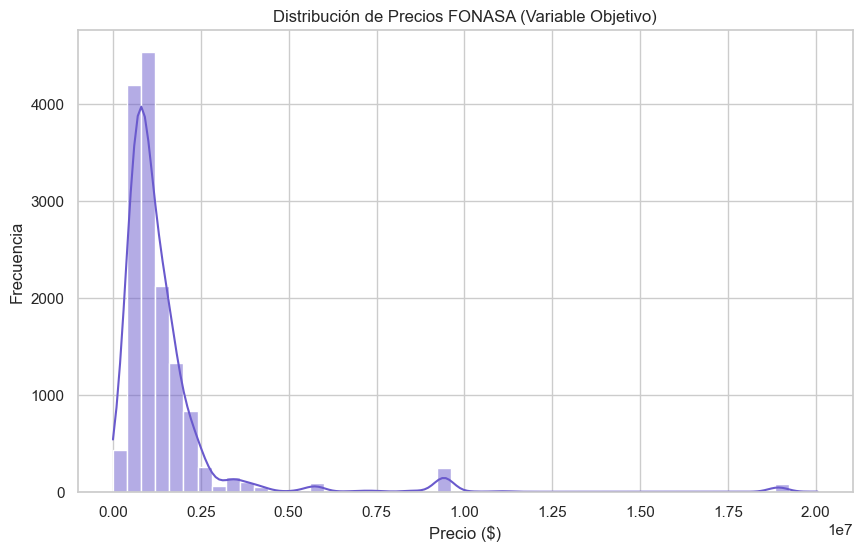

In [ ]:
# Visualización Inicial: Distribución del Costo
plt.figure(figsize=(10, 6))
sns.histplot(df['Precio FONASA 2016'], bins=50, kde=True, color='slateblue')
plt.title('Distribución de Precios FONASA (Variable Objetivo)')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.show()

### 2.2 Tratamiento Demográfico y Normalización del Target
Los costos hospitalarios presentan una distribución fuertemente sesgada hacia la derecha (pocos pacientes concentran costos altísimos). Para estabilizar la varianza y mejorar el aprendizaje de los modelos de regresión, aplicamos una transformación logarítmica (`log1p`) a la variable objetivo (Precio FONASA).

In [ ]:
#  Feature Engineering: Demografía y Transformación del Target
# 1. Limpieza de Edad (extraemos solo números por si hay celdas con texto)
df['Edad_clean'] = df['Edad en años'].astype(str).str.extract(r'(\d+)').astype(float)
df['Edad_clean'] = df['Edad_clean'].fillna(df['Edad_clean'].median())

# 2. Variable Sexo (Convertimos a numérico: 1 para Masculino, 0 para Femenino/Otro)
df['Sexo_M'] = (df['Sexo (Desc)'].astype(str).str.upper().str.startswith('M')).astype(int)

# 3. Transformación del Target (Precios sesgados)
# Usamos log1p (logaritmo de 1 + x) para normalizar la curva y ayudar al modelo a aprender mejor
df['Precio_Log'] = np.log1p(df['Precio FONASA 2016'])

In [ ]:
# Preparación de Matrices X e y para el Modelo
# Unimos las variables demográficas con nuestra "Bolsa de Diagnósticos" (df_diags)
X_demografia = df[['Edad_clean', 'Sexo_M']]
X = pd.concat([X_demografia, df_diags], axis=1)

y = df['Precio_Log'] # Entrenaremos prediciendo el logaritmo del precio

# División en Train y Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Set de entrenamiento (X): {X_train.shape}")
print(f"Set de prueba (X): {X_test.shape}")

Set de entrenamiento (X): (11648, 3650)
Set de prueba (X): (2913, 3650)


## 3. Entrenamiento y Evaluación de Modelos
Sometemos nuestra matriz de características (más de 3,600 variables) a tres enfoques algorítmicos distintos para evaluar su rendimiento frente a la "maldición de la dimensionalidad":
1. **Regresión Lineal:** Modelo paramétrico base (Baseline).
2. **Random Forest Regressor:** Ensamble no paramétrico basado en múltiples árboles independientes.
3. **Gradient Boosting Regressor:** Ensamble secuencial centrado en la minimización iterativa del error.

*Las métricas principales de evaluación serán el Error Absoluto Medio (MAE) para interpretabilidad financiera, y el Coeficiente de Determinación ($R^2$).*

### 3.1 Entrenamiento Modelo 1: Regresión Lineal

In [ ]:
# Modelo 1: Regresión Lineal (Baseline)
print("Entrenando Regresión Lineal...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predicciones y transformación inversa del logaritmo a pesos reales ($)
preds_log_lr = model_lr.predict(X_test)
preds_orig_lr = np.expm1(preds_log_lr)

# Variable real en pesos para comparar en todos los modelos
y_test_orig = np.expm1(y_test)

# Cálculo de métricas
mae_lr = mean_absolute_error(y_test_orig, preds_orig_lr)
r2_lr = r2_score(y_test_orig, preds_orig_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_orig, preds_orig_lr))

print(f"Resultados Regresión Lineal -> MAE: ${mae_lr:,.0f} | R²: {r2_lr:.4f} | RMSE: ${rmse_lr:,.0f}")

Entrenando Regresión Lineal...
Resultados Regresión Lineal -> MAE: $1,464,637 | R²: -127.7846 | RMSE: $22,640,120


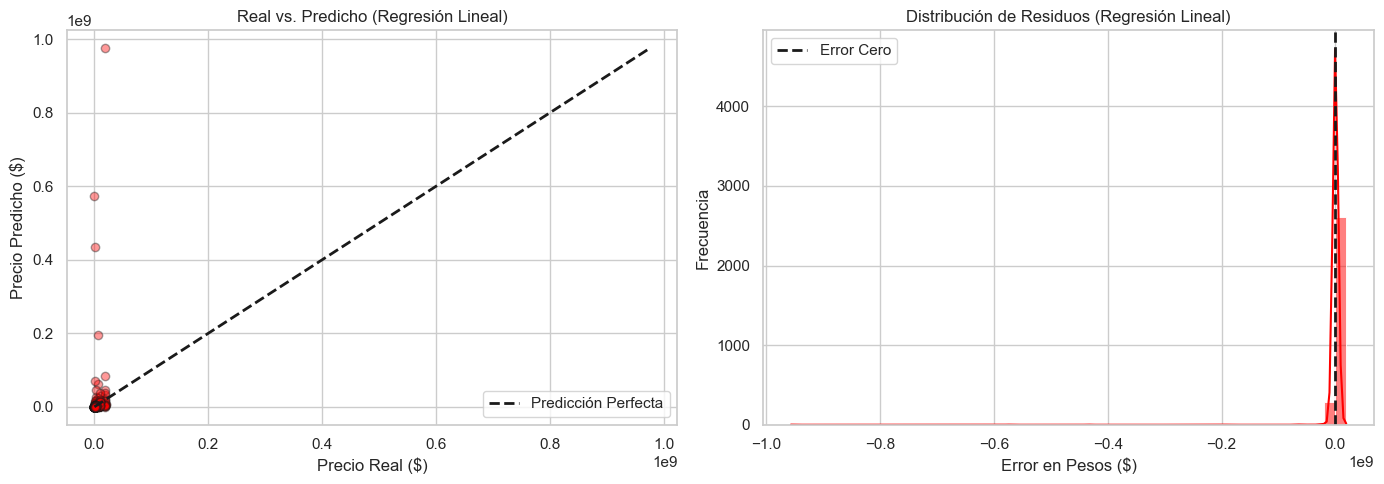

In [48]:
# Evaluación Visual del Modelo
plt.figure(figsize=(14, 5))

# 1. Gráfico de Predicción vs Realidad
plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, preds_orig_lr, alpha=0.4, color='red', edgecolor='k')
max_val = max(y_test_orig.max(), preds_orig_lr.max())
plt.plot([0, max_val], [0, max_val], 'k--', lw=2, label='Predicción Perfecta')
plt.title('Real vs. Predicho (Regresión Lineal)')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()

# 2. Gráfico de Residuos (Errores)
plt.subplot(1, 2, 2)
residuos_lr = y_test_orig - preds_orig_lr
sns.histplot(residuos_lr, bins=50, kde=True, color='red')
plt.axvline(x=0, color='k', linestyle='--', lw=2, label='Error Cero')
plt.title('Distribución de Residuos (Regresión Lineal)')
plt.xlabel('Error en Pesos ($)')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

### 3.2 Entrenamiento Modelo 2: Random Forest Regressor

In [ ]:
# Modelo 2: Random Forest Regressor
print("Entrenando Random Forest Regressor...")
# n_jobs=-1 usa todos los núcleos para ir más rápido
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Predicciones
preds_log_rf = model_rf.predict(X_test)
preds_orig_rf = np.expm1(preds_log_rf)

# Cálculo de métricas
mae_rf = mean_absolute_error(y_test_orig, preds_orig_rf)
r2_rf = r2_score(y_test_orig, preds_orig_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, preds_orig_rf))

print(f"Resultados Random Forest -> MAE: ${mae_rf:,.0f} | R²: {r2_rf:.4f} | RMSE: ${rmse_rf:,.0f}")

Entrenando Random Forest Regressor...
Resultados Random Forest -> MAE: $547,469 | R²: 0.4715 | RMSE: $1,450,300


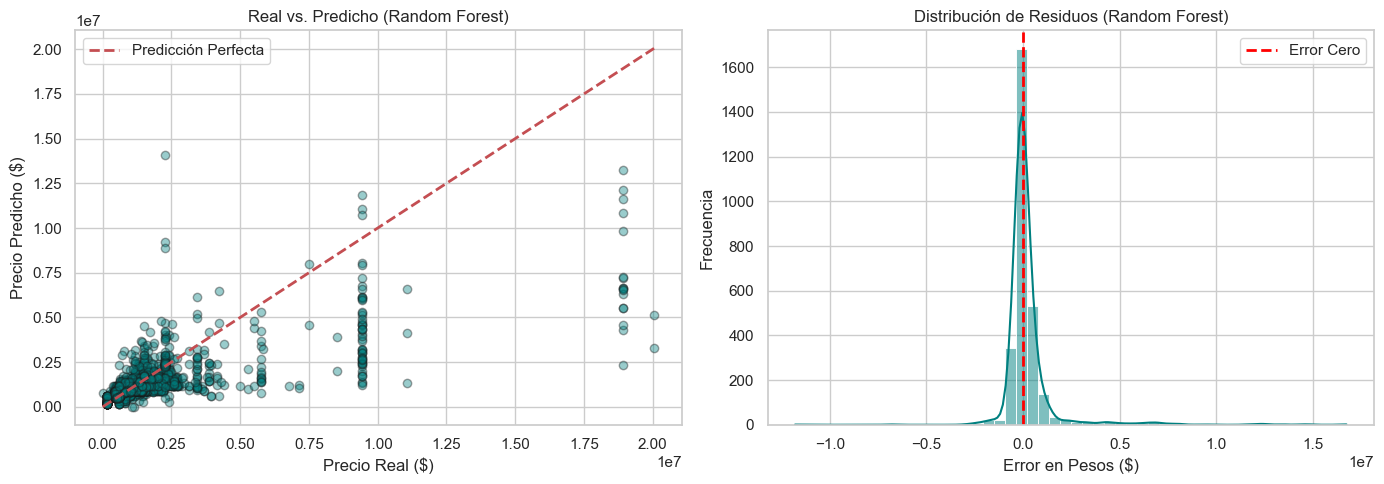

In [51]:
# Evaluación Visual del Modelo
plt.figure(figsize=(14, 5))

# 1. Gráfico de Predicción vs Realidad
plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, preds_orig_rf, alpha=0.4, color='teal', edgecolor='k')
max_val = max(y_test_orig.max(), preds_orig_rf.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Predicción Perfecta')
plt.title('Real vs. Predicho (Random Forest)')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()

# 2. Gráfico de Residuos (Errores)
plt.subplot(1, 2, 2)
residuos_rf = y_test_orig - preds_orig_rf
sns.histplot(residuos_rf, bins=50, kde=True, color='teal')
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Error Cero')
plt.title('Distribución de Residuos (Random Forest)')
plt.xlabel('Error en Pesos ($)')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

### 3.3 Entrenamiento Modelo 3: Gradient Boosting Regressor

In [ ]:
# Modelo 3: Gradient Boosting Regressor
print("Entrenando Gradient Boosting Regressor...")
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model_gb.fit(X_train, y_train)

# Predicciones
preds_log_gb = model_gb.predict(X_test)
preds_orig_gb = np.expm1(preds_log_gb)

# Cálculo de métricas
mae_gb = mean_absolute_error(y_test_orig, preds_orig_gb)
r2_gb = r2_score(y_test_orig, preds_orig_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test_orig, preds_orig_gb))

print(f"Resultados Gradient Boosting -> MAE: ${mae_gb:,.0f} | R²: {r2_gb:.4f} | RMSE: ${rmse_gb:,.0f}")

Entrenando Gradient Boosting Regressor...
Resultados Gradient Boosting -> MAE: $535,838 | R²: 0.4523 | RMSE: $1,476,393


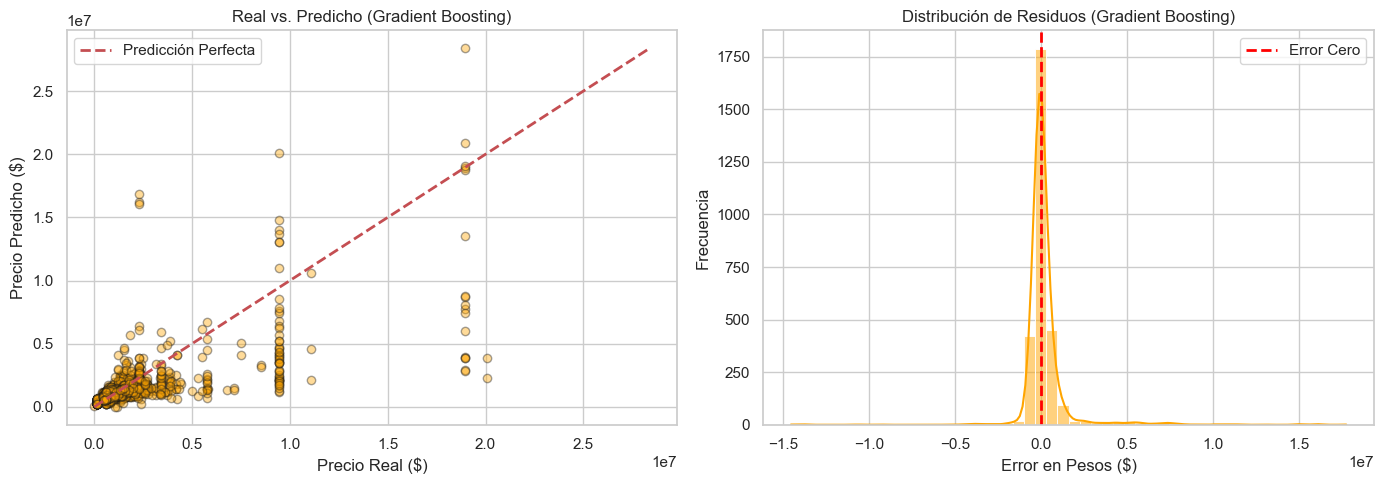

In [50]:
# Evaluación Visual del Modelo
plt.figure(figsize=(14, 5))

# 1. Gráfico de Predicción vs Realidad
plt.subplot(1, 2, 1)
plt.scatter(y_test_orig, preds_orig_gb, alpha=0.4, color='orange', edgecolor='k')
max_val = max(y_test_orig.max(), preds_orig_gb.max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Predicción Perfecta')
plt.title('Real vs. Predicho (Gradient Boosting)')
plt.xlabel('Precio Real ($)')
plt.ylabel('Precio Predicho ($)')
plt.legend()

# 2. Gráfico de Residuos (Errores)
plt.subplot(1, 2, 2)
residuos_gb = y_test_orig - preds_orig_gb
sns.histplot(residuos_gb, bins=50, kde=True, color='orange')
plt.axvline(x=0, color='red', linestyle='--', lw=2, label='Error Cero')
plt.title('Distribución de Residuos (Gradient Boosting)')
plt.xlabel('Error en Pesos ($)')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

## 4. Resultados y Análisis de Características
A continuación, consolidamos las métricas de los tres algoritmos para justificar la elección del modelo definitivo. Finalmente, extraemos la importancia relativa de las variables (Feature Importance) de la arquitectura Random Forest para entender qué diagnósticos médicos son los mayores detonantes del costo hospitalario.


--- TABLA COMPARATIVA ---


,Modelo,MAE ($),R²,RMSE ($)
2,Gradient Boosting,"$535,838",0.4523,"$1,476,393"
1,Random Forest,"$547,469",0.4715,"$1,450,300"
0,Regresión Lineal,"$1,464,637",-127.7846,"$22,640,120"


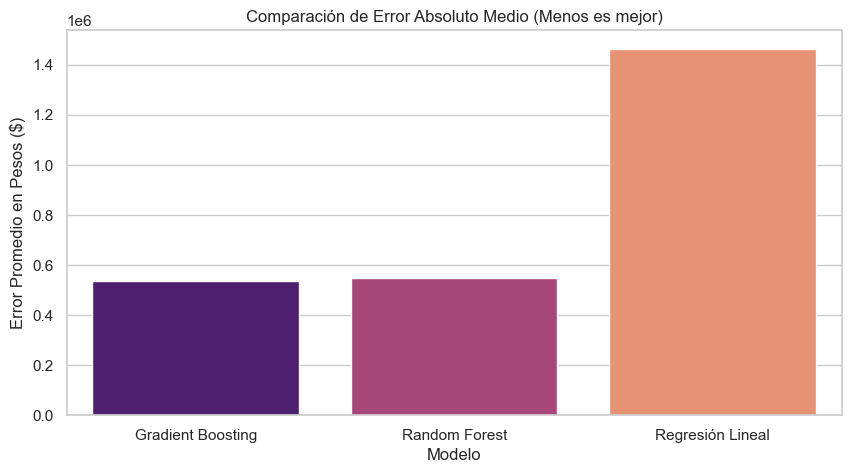

In [ ]:
# Consolidamos las métricas guardadas en los pasos anteriores
resultados = [
    {"Modelo": "Regresión Lineal", "MAE ($)": mae_lr, "R²": r2_lr, "RMSE ($)": rmse_lr},
    {"Modelo": "Random Forest", "MAE ($)": mae_rf, "R²": r2_rf, "RMSE ($)": rmse_rf},
    {"Modelo": "Gradient Boosting", "MAE ($)": mae_gb, "R²": r2_gb, "RMSE ($)": rmse_gb}
]

df_res = pd.DataFrame(resultados).sort_values(by="MAE ($)")

print("\n--- TABLA COMPARATIVA ---")
df_pretty = df_res.copy()
df_pretty["MAE ($)"] = df_pretty["MAE ($)"].apply(lambda x: f"${x:,.0f}")
df_pretty["RMSE ($)"] = df_pretty["RMSE ($)"].apply(lambda x: f"${x:,.0f}")
df_pretty["R²"] = df_pretty["R²"].round(4)
display(df_pretty)

# Gráfico comparativo
plt.figure(figsize=(10, 5))
sns.barplot(data=df_res, x="Modelo", y="MAE ($)", hue="Modelo", palette="magma", legend=False)
plt.title("Comparación de Error Absoluto Medio (Menos es mejor)")
plt.ylabel("Error Promedio en Pesos ($)")
plt.show()

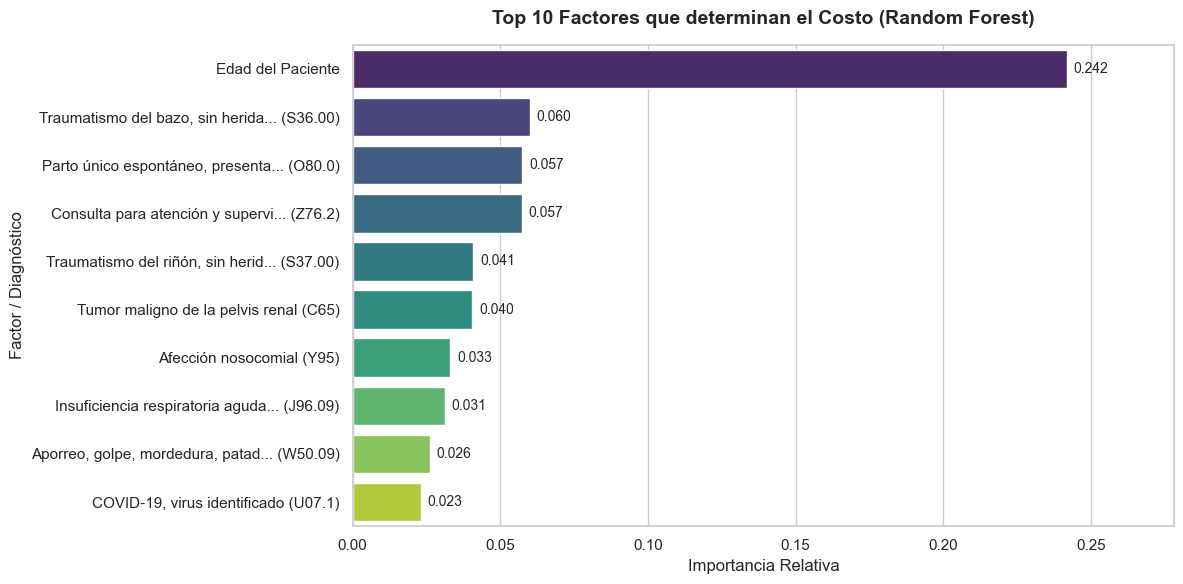

In [ ]:
# Diagnósticos más influyentes (Feature Importance)
# 1. Diccionario de mapeo con nombres limpios para las variables demográficas
diag_cols = [col for col in df.columns if 'Diag' in col]
diccionario_diags = {
    'Edad_clean': 'Edad del Paciente',
    'Sexo_M': 'Sexo (Masculino)'
}

for col in diag_cols:
    for val in df[col].dropna().unique():
        if val != '-':
            partes = str(val).split(' - ', 1)
            if len(partes) == 2:
                codigo = partes[0].strip()
                desc = partes[1].strip()
                # Truncar textos a 35 caracteres fijos para mantener el eje y alineado y limpio
                desc_corta = desc if len(desc) <= 35 else desc[:32] + "..."
                diccionario_diags[codigo] = f"{desc_corta} ({codigo})"

# 2. Extraer las importancias del mejor modelo (Random Forest)
importances = model_rf.feature_importances_
feat_imp = pd.DataFrame({'Feature': X.columns, 'Imp': importances})

# 3. Traducir las características
feat_imp['Nombre_Legible'] = feat_imp['Feature'].map(diccionario_diags).fillna(feat_imp['Feature'])

# 4. Ordenar y seleccionar el top 10
top_feat_imp = feat_imp.sort_values('Imp', ascending=False).head(10)

# 5. Generar un gráfico con calidad de publicación (estilo paper)
plt.figure(figsize=(12, 6)) # Figura más ancha
ax = sns.barplot(data=top_feat_imp, x="Imp", y="Nombre_Legible", hue="Nombre_Legible", palette="viridis", legend=False)

# Añadir los valores numéricos al final de cada barra
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5, fontsize=10)

# Ajustes estéticos
plt.title("Top 10 Factores que determinan el Costo (Random Forest)", pad=15, fontsize=14, fontweight='bold')
plt.xlabel("Importancia Relativa", fontsize=12)
plt.ylabel("Factor / Diagnóstico", fontsize=12)
# Damos 15% más de margen a la derecha para que los números no se corten
plt.xlim(0, top_feat_imp['Imp'].max() * 1.15) 
plt.tight_layout()
plt.show()

In [53]:
# %% [15] Exportación del Modelo a Producción
import joblib
import os

# Creamos una carpeta para mantener el repositorio ordenado
os.makedirs('modelos_exportados', exist_ok=True)

# Guardamos el modelo ganador y el transformador de diagnósticos
joblib.dump(model_rf, 'modelos_exportados/random_forest_grd.pkl')
joblib.dump(mlb, 'modelos_exportados/multilabel_binarizer.pkl')

print("✅ Modelo y transformador exportados exitosamente en la carpeta 'modelos_exportados'.")

✅ Modelo y transformador exportados exitosamente en la carpeta 'modelos_exportados'.
